In [21]:
import torch
import torch.nn as nn
import pandas as pd
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, random_split
from collections import Counter
import random

In [22]:
""" SHARED_LABEL_MAP = {
    'W': 0, # Walking
    'R': 1, # Running
    'J': 2, # Jumping
    'L': 3, # Sitting Still
    'S': 4, # Standing Still
    'C': 5, # Sitting down / Standing up transition
    'H': 6  # (H is often used for the same arm gym activity)
} """

SHARED_LABEL_MAP = {
    'E': 0, # Empty Room
    'W': 1, # Walking
    'R': 2, # Running
    'J': 3, # Jumping
    'L': 4, # Sitting Still
    'S': 5, # Standing Still
    'C': 6, # Sitting down / Standing up transition
    'H': 7  # (H is often used for the same arm gym activity)
}

SET_INFO_MAP = {
    'S1': {'person': 0, 'env': 0},
    'S2': {'person': 0, 'env': 0},
    'S3': {'person': 1, 'env': 0},
    'S4': {'person': 0, 'env': 1},
    'S5': {'person': 1, 'env': 1},
    'S6': {'person': 0, 'env': 2},
    'S7': {'person': 2, 'env': 3},
}

""" # We want Val/Test to be normalized like Train, but NOT masked/noisy.
class NormalizeOnly:
    def __call__(self, x):
        return (x - np.mean(x)) / (np.std(x) + 1e-8) """

' # We want Val/Test to be normalized like Train, but NOT masked/noisy.\nclass NormalizeOnly:\n    def __call__(self, x):\n        return (x - np.mean(x)) / (np.std(x) + 1e-8) '

In [23]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

torch.set_float32_matmul_precision('high')

class OPERAnetDataset(Dataset):
    def __init__(self, root_dir, subjects_to_include=None, window_size=340, step_size=170, transform=None):
        self.samples = []
        self.transform = transform
        self.label_map = SHARED_LABEL_MAP

        # Use a temporary list to store paths first
        print(f"Pre-loading data into RAM...")
        
        for root, _, files in os.walk(root_dir):
            folder_name = os.path.basename(root)
            subject_id = folder_name[:2]
            if subjects_to_include is not None and subject_id not in subjects_to_include:
                continue

            for file in files:
                if file.endswith(".txt"):
                    try:
                        code = file.split('_')[1][0].upper()
                        if code in self.label_map:
                            file_path = os.path.join(root, file)
                            # LOAD THE ENTIRE FILE INTO RAM NOW
                            data = np.load(file_path, allow_pickle=True).astype(np.float32)
                            label = self.label_map[code]
                            
                            for start in range(0, data.shape[0] - window_size + 1, step_size):
                                # Slice and store the actual array, not the path
                                window = data[start : start + window_size, :]
                                self.samples.append((window, label))
                    except Exception:
                        continue
        print(f"Loaded {len(self.samples)} windows into RAM.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        window, label = self.samples[idx]
        
        # Apply Data Augmentation (Step 2)
        if self.transform:
            window = self.transform(window)
        
        tensor_x = torch.from_numpy(window).unsqueeze(0) # (1, 340, 100)
        tensor_y = torch.tensor(label, dtype=torch.long)
        return tensor_x, tensor_y



In [24]:
""" class WirelessAugment:
    def __init__(self, time_mask_max=30, freq_mask_max=10, p=0.5):
        self.time_mask_max = time_mask_max
        self.freq_mask_max = freq_mask_max
        self.p = p

    def __call__(self, x):
        # Apply random noise/masking only with probability p
        if random.random() < self.p:
            # 1. Gaussian Noise
            x = x + np.random.normal(0, 0.01, x.shape).astype(np.float32)
            # 2. Time Mask
            t = np.random.randint(0, self.time_mask_max)
            t0 = np.random.randint(0, x.shape[0] - t)
            x[t0:t0+t, :] = 0
            # 3. Freq Mask
            f = np.random.randint(0, self.freq_mask_max)
            f0 = np.random.randint(0, x.shape[1] - f)
            x[:, f0:f0+f] = 0

        # ALWAYS NORMALIZE (Keep this outside the if-block)
        x = (x - np.mean(x)) / (np.std(x) + 1e-8)
        return x """

' class WirelessAugment:\n    def __init__(self, time_mask_max=30, freq_mask_max=10, p=0.5):\n        self.time_mask_max = time_mask_max\n        self.freq_mask_max = freq_mask_max\n        self.p = p\n\n    def __call__(self, x):\n        # Apply random noise/masking only with probability p\n        if random.random() < self.p:\n            # 1. Gaussian Noise\n            x = x + np.random.normal(0, 0.01, x.shape).astype(np.float32)\n            # 2. Time Mask\n            t = np.random.randint(0, self.time_mask_max)\n            t0 = np.random.randint(0, x.shape[0] - t)\n            x[t0:t0+t, :] = 0\n            # 3. Freq Mask\n            f = np.random.randint(0, self.freq_mask_max)\n            f0 = np.random.randint(0, x.shape[1] - f)\n            x[:, f0:f0+f] = 0\n\n        # ALWAYS NORMALIZE (Keep this outside the if-block)\n        x = (x - np.mean(x)) / (np.std(x) + 1e-8)\n        return x '

In [25]:
class MultiAntennaTestDataset(Dataset):
    def __init__(self, root_dir, window_size=340, step_size=170):
        self.samples = []
        self.label_map = SHARED_LABEL_MAP

        print(f"Loading multi-antenna files from {root_dir}...")
        for root, _, files in os.walk(root_dir):
            for file in files:
                # Only look for stream 1, we will automatically load the others
                if file.endswith("stream_0.txt"):
                    try:
                        parts = file.split('_')
                        if len(parts) < 2:
                            continue
                        
                        # FIX 1: Extract first character to handle suffixes like 'J3' -> 'J'
                        code = parts[1][0].upper()
                        if code in self.label_map:
                            label = self.label_map[code]
                            base_filename = file.replace("_stream_0.txt", "")
                            base_path = os.path.join(root, base_filename)
                            
                            # Load all 4 streams to ensure they are the exact same length
                            streams = []
                            for i in range(4):
                                stream_file = f"{base_path}_stream_{i}.txt"
                                
                                # FIX 2: If stream 4 (or any stream) is missing on disk, fallback to stream 1
                                if not os.path.exists(stream_file):
                                    stream_file = f"{base_path}_stream_0.txt"
                                
                                streams.append(np.load(stream_file, allow_pickle=True).astype(np.float32))
                            
                            length = streams[0].shape[0]
                            
                            # Slice into 340-frame windows
                            for start in range(0, length - window_size + 1, step_size):
                                end = start + window_size
                                self.samples.append(([s[start:end, :] for s in streams], label))
                    except Exception as e:
                        print(f"Skipped {file} due to error: {e}")
                        continue
                        
        print(f"Successfully loaded {len(self.samples)} multi-antenna windows!")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        streams, label = self.samples[idx]
        
        processed_tensors = []
        for s in streams:
            # Z-Score Standardization: (x - mean) / std
            # This makes Subject 7's signal look exactly like Subject 1's signal scale
            processed_tensors.append(torch.from_numpy(s).unsqueeze(0))
        
        return processed_tensors[0], processed_tensors[1], \
               processed_tensors[2], processed_tensors[3], \
               torch.tensor(label, dtype=torch.long)

In [26]:
""" """ # --- 1. Define Subject Groups for Independent Evaluation ---
# S1-S5: Training (Multiple environments/people)
# S6: Validation (Checking performance on a new person during training)
# S7: Testing (The ultimate "Independent" test as per the paper)
train_subs = ['S1', 'S2', 'S3', 'S4', 'S5']
val_subs   = ['S6']
test_subs  = ['S7']



# --- 3. Initialize the Datasets Independently ---
# Note: We apply WirelessAugment ONLY to the training set.
train_dataset = OPERAnetDataset(
    root_dir="doppler_traces", 
    subjects_to_include=train_subs, 
    #transform=WirelessAugment(p=0.5) # Apply noise/masking
)

val_dataset = OPERAnetDataset(
    root_dir="doppler_traces", 
    subjects_to_include=val_subs, 
    #transform=NormalizeOnly() # Only scale the data
)

test_dataset = OPERAnetDataset(
    root_dir="doppler_traces", 
    subjects_to_include=test_subs, 
    #transform=NormalizeOnly() # Only scale the data
)

# --- 4. Create the DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"--- Dataset Split Summary ---")
print(f"Train (S1-S5): {len(train_dataset)} windows | Batches: {len(train_loader)}")
print(f"Val   (S6):    {len(val_dataset)} windows | Batches: {len(val_loader)}")
print(f"Test  (S7):    {len(test_dataset)} windows | Batches: {len(test_loader)}") 

Pre-loading data into RAM...
Loaded 28120 windows into RAM.
Pre-loading data into RAM...
Loaded 5692 windows into RAM.
Pre-loading data into RAM...
Loaded 3372 windows into RAM.
--- Dataset Split Summary ---
Train (S1-S5): 28120 windows | Batches: 440
Val   (S6):    5692 windows | Batches: 45
Test  (S7):    3372 windows | Batches: 27


In [27]:
class BaseLineModel(nn.Module):
    def __init__(self, num_classes=8, dropout=0.2):
        super().__init__()
        
        # Branch 1: Spatial Reduction
        self.branch1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Branch 2: Simple Feature Extraction
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=5, kernel_size=2, stride=2),
            nn.BatchNorm2d(5),
            nn.ReLU()
        )
        
        # Branch 3: Multi-scale Feature Extraction (from SHARP paper)
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=3, kernel_size=1, stride=1),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=2, stride=1, padding=1), # padding to keep size
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.Conv2d(in_channels=6, out_channels=9, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(9),
            nn.ReLU()
        )
        
        # Branch 1 output (1 channel) + Branch 2 (5 channels) + Branch 3 (9 channels) = 15 channels
        self.concat_conv = nn.Sequential(
            nn.Conv2d(in_channels=15, out_channels=3, kernel_size=1, stride=1),
            nn.BatchNorm2d(3),
            nn.ReLU()
        )
        
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(dropout)
        # Assuming 340x100 input -> after stride 2 branches -> 170x50
        self.dense = nn.Linear(3 * 170 * 50, num_classes)
    
    def forward(self, x):
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out3 = self.branch3(x)
        
        # Ensure all branches have the same spatial dimensions before concat
        # (Slight resizing might be needed if window size isn't perfectly divisible)
        x = torch.cat([out1, out2, out3], dim=1)
        x = self.concat_conv(x)
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.dense(x)
        return x

In [28]:
def sharp_decision_fusion(logits_list):
    """
    logits_list: A list of 4 tensors, each of shape [batch_size, num_classes]
    Returns: A tensor of final predicted labels of shape [batch_size]
    """
    # Stack into shape: [4, batch_size, num_classes]
    stacked_logits = torch.stack(logits_list) 
    
    # Get individual predictions: Shape [4, batch_size]
    stacked_preds = torch.argmax(stacked_logits, dim=2) 
    
    final_preds = []
    batch_size = stacked_preds.shape[1]
    
    # Iterate through each sample in the batch
    for i in range(batch_size):
        preds_for_sample = stacked_preds[:, i].tolist()
        
        # Count the votes
        counts = Counter(preds_for_sample)
        most_common_pred, count = counts.most_common(1)[0]
        
        # SHARP Rule: If at least 3 out of 4 antennas agree
        if count >= 3:
            final_preds.append(most_common_pred)
        else:
            # Tie-breaker: Sum the raw logits across all 4 antennas for this sample
            summed_logits = torch.sum(stacked_logits[:, i, :], dim=0) # Shape: [num_classes]
            final_preds.append(torch.argmax(summed_logits).item())
            
    return torch.tensor(final_preds, device=logits_list[0].device)

In [29]:
def soft_decision_fusion(logits_list):
    """
    Applies Softmax to convert logits to probabilities, then averages them.
    This prevents one loud/wrong antenna from dominating the decision.
    """
    # 1. Convert all logits to probabilities
    probs_list =[torch.softmax(logits, dim=1) for logits in logits_list]
    
    # 2. Stack and average the probabilities:[4, batch_size, num_classes] -> [batch_size, num_classes]
    avg_probs = torch.mean(torch.stack(probs_list), dim=0)
    
    # 3. Final prediction is the class with the highest average probability
    return torch.argmax(avg_probs, dim=1)

In [30]:
import torch.optim as optim
from tqdm import tqdm # Optional: for progress bars

# 1. Device Configuration
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Initialize Model, Loss, and Optimizer
model = BaseLineModel(num_classes=8, dropout=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# To help the model converge better on augmented data
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

best_val_acc = 0.0
num_epochs = 10 # Increase this if using Augmentation, as it takes longer to learn

print("Starting Training...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    # Using tqdm for a nice progress bar
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train")
    for batch_x, batch_y in loop:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # Forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item() * batch_x.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item() * batch_x.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    # Update Learning Rate Scheduler
    #scheduler.step(epoch_val_acc)
    scheduler.step()

    # --- RECORD HISTORY (Fixed placement) ---
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    # Save Best Model Weights
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_sharp_model.pth')
        print(f"--> Best model saved with Val Acc: {best_val_acc:.4f}")

    print(f"Epoch [{epoch+1}/{num_epochs}] Summary: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

# --- 4. FINAL TESTING PHASE WITH FUSION ---

# IMPORTANT: Load the BEST weights found during training before testing
model.load_state_dict(torch.load('best_sharp_model.pth'))
model.eval()

# Ensure MultiAntennaTestDataset also uses normalization
test_dataset_fusion = MultiAntennaTestDataset(root_dir="doppler_traces/S7a")
test_loader_fusion = DataLoader(test_dataset_fusion, batch_size=64, shuffle=False)

print("\nRunning SHARP Decision Fusion on Subject 7 (Unseen)...")
test_correct, test_total = 0, 0

with torch.no_grad():
    for x1, x2, x3, x4, labels in test_loader_fusion:
        # Move all antennas and labels to device
        x1, x2, x3, x4 = x1.to(device), x2.to(device), x3.to(device), x4.to(device)
        labels = labels.to(device)
        
        # Optional: Manual Normalization if not in Dataset __getitem__
        # x1 = (x1 - x1.mean()) / (x1.std() + 1e-8) ... (repeat for all)

        logits = [model(x1), model(x2), model(x3), model(x4)]
        
        # Apply Fusion
        final_predictions = sharp_decision_fusion(logits)
        
        # Ensure predictions are on the same device as labels for comparison
        final_predictions = final_predictions.to(device)
        
        test_total += labels.size(0)
        test_correct += (final_predictions == labels).sum().item()

test_acc = test_correct / test_total
print(f"\nFINAL RESULT:")
print(f"SHARP Fusion Test Accuracy (Subject 7): {test_acc:.4f} ({test_acc * 100:.2f}%)")

Using device: cuda
Starting Training...


Epoch [1/10] Train: 100%|██████████| 440/440 [00:11<00:00, 38.45it/s]


--> Best model saved with Val Acc: 0.1543
Epoch [1/10] Summary: Train Loss: 1.5006, Train Acc: 0.4018 | Val Loss: 19.9849, Val Acc: 0.1543


Epoch [2/10] Train: 100%|██████████| 440/440 [00:10<00:00, 40.46it/s]


--> Best model saved with Val Acc: 0.2063
Epoch [2/10] Summary: Train Loss: 1.1784, Train Acc: 0.5048 | Val Loss: 8.8481, Val Acc: 0.2063


...

Epoch [8/10] Summary: Train Loss: 0.7846, Train Acc: 0.6740 | Val Loss: 31.6865, Val Acc: 0.1702


Epoch [9/10] Train: 100%|██████████| 440/440 [00:10<00:00, 40.00it/s]


Epoch [9/10] Summary: Train Loss: 0.7338, Train Acc: 0.6956 | Val Loss: 2.0275, Val Acc: 0.3978


Epoch [10/10] Train: 100%|██████████| 440/440 [00:10<00:00, 40.07it/s]


Epoch [10/10] Summary: Train Loss: 0.7033, Train Acc: 0.7060 | Val Loss: 14.1606, Val Acc: 0.3204
Loading multi-antenna files from doppler_traces/S7a...
Successfully loaded 843 multi-antenna windows!

Running SHARP Decision Fusion on Subject 7 (Unseen)...

FINAL RESULT:
SHARP Fusion Test Accuracy (Subject 7): 0.3654 (36.54%)


In [46]:
import pytorch_lightning as L
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
class OPERAnetDataModule(L.LightningDataModule):
    def __init__(self, root_dir, batch_size=64):
        super().__init__()
        self.root_dir = root_dir
        self.batch_size = batch_size
        # Step 1 logic: Subject Splits
        self.train_subs = ['S1', 'S2', 'S3', 'S4', 'S5']
        self.val_subs = ['S6']
        self.test_subs = ['S7']

    def setup(self, stage=None):
        if stage == "fit" or stage is None:
            self.train_ds = OPERAnetDataset(
                self.root_dir, subjects_to_include=self.train_subs,
                #transform=transforms.Compose([NormalizeOnly(), WirelessAugment(p=0.8)]) # Strong augmentation
            )
            self.val_ds = OPERAnetDataset(
                self.root_dir, subjects_to_include=self.val_subs,
                #transform=NormalizeOnly()
            )
        if stage == "test":
            # Uses the Multi-Antenna class for the SHARP fusion test
            self.test_ds = MultiAntennaTestDataset(root_dir=f"{self.root_dir}/S7a")

    def train_dataloader(self):
        return DataLoader(
            self.train_ds, 
            batch_size=self.batch_size, 
            shuffle=True, 
            num_workers=0,        
            pin_memory=True,      # Stages the data in a special memory area for lightning-fast GPU transfer
            persistent_workers=False # Keeps the workers alive between epochs to save startup time
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds, 
            batch_size=self.batch_size, 
            num_workers=0, 
            pin_memory=True,
            persistent_workers=False
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_ds, 
            batch_size=self.batch_size, 
            num_workers=0, 
            pin_memory=True
        )

In [49]:
import torch.nn.functional as F
import torchmetrics

class LitSHARP(L.LightningModule):
    def __init__(self, num_classes=8, lr=1e-3, dropout=0.2, weight_decay=1e-4):
        super().__init__()
        self.save_hyperparameters() # Important for Optuna!
        self.model = BaseLineModel(num_classes=num_classes)
        # Update dropout dynamically for Optuna tuning
        self.model.dropout = torch.nn.Dropout(dropout)
        
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_preds = []
        self.test_labels = []
        

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        # Add label_smoothing=0.1
        loss = F.cross_entropy(logits, y, label_smoothing=0.1) 
        
        self.train_acc(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        # Validation loss doesn't technically need smoothing, but keeps metrics aligned
        loss = F.cross_entropy(logits, y) 
        
        self.val_acc(logits, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        # Unpack the 4 antenna streams from MultiAntennaTestDataset
        x1, x2, x3, x4, y = batch
        
        # Get logits for all 4
        logits = self(x1), self(x2), self(x3), self(x4)
        
        # Apply the SHARP Fusion logic we defined earlier
        # Note: sharp_decision_fusion must be accessible here
        
        # preds = sharp_decision_fusion([l1, l2, l3, l4])
        preds = soft_decision_fusion(logits)
        self.test_preds.extend(preds.cpu().numpy())
        self.test_labels.extend(y.cpu().numpy())

        acc = (preds == y).float().mean()
        self.log("test_fusion_acc", acc)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.hparams.lr,
            total_steps=self.trainer.estimated_stepping_batches, # Lightning automatically calculates this
            pct_start=0.3, # Spend 30% of time warming up
            anneal_strategy='cos'
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "monitor": "val_acc", "interval": "step"}
        }

In [50]:
import optuna
from optuna.integration import PyTorchLightningPruningCallback

def objective(trial):
    # 1. Suggest Hyperparameters
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = 0.2
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    weight_decay = trial.suggest_float("weight_decay",1e-8, 1e-5, log=True )
    
    print(f"\n🚀 STARTING TRIAL {trial.number}")
    print(f"Using Parameters: {trial.params}\n")
    
    # 2. Setup Lightning components
    model = LitSHARP(num_classes=8, lr=lr, dropout=dropout, weight_decay = weight_decay)
    datamodule = OPERAnetDataModule(root_dir="doppler_traces", batch_size=batch_size)

    # 3. Setup Trainer (Use a short run for tuning) find hyperparameters
    trainer = L.Trainer(
        num_sanity_val_steps=0,
        max_epochs=8,
        enable_progress_bar=False,
        accelerator="auto",
        devices=1,
        logger=False, # Disable logging for speed during tuning
        enable_checkpointing=False,
        callbacks=[PyTorchLightningPruningCallback(trial, monitor="val_acc")],
        precision="16-mixed"
        
    )

    # 4. Train and return the metric for Optuna to maximize
    trainer.fit(model, datamodule=datamodule)
    return trainer.callback_metrics["val_acc"].item()



In [51]:
def print_trial_status(study, trial):
    # Check if the trial actually finished, or if the Pruner killed it early
    if trial.state == optuna.trial.TrialState.COMPLETE:
        print(f"\n✅ TRIAL {trial.number} FINISHED")
        print(f"   Accuracy: {trial.value:.4f}")
        print(f"   Params:   {trial.params}")
        print(f"🏆 BEST SO FAR: {study.best_value:.4f} (from Trial {study.best_trial.number})\n")
        
    elif trial.state == optuna.trial.TrialState.PRUNED:
        print(f"\n✂️ TRIAL {trial.number} PRUNED (Killed early for low performance)\n")

[I 2026-05-07 23:01:18,072] A new study created in memory with name: no-name-e4df4d2f-ad9a-4e8f-be1c-e3da93971403
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



🚀 STARTING TRIAL 0
Using Parameters: {'lr': 0.0005958388396795414, 'batch_size': 64, 'weight_decay': 5.96105511947333e-08}

Pre-loading data into RAM...
Loaded 28120 windows into RAM.
Pre-loading data into RAM...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | model     | BaseLineModel      | 205 K  | train | 0    
1 | train_acc | MulticlassAccuracy | 0      | train | 0    
2 | val_acc   | MulticlassAccuracy | 0      | train | 0    
-----------------------------------------------------------------
205 K     Trainable params
0         Non-trainable params
205 K     Total params
0.820     Total estimated model params size (MB)
25        Modules in train mode
0         Modules in eval mode
0         Total Flops


Loaded 5692 windows into RAM.


`Trainer.fit` stopped: `max_epochs=8` reached.
[I 2026-05-07 23:06:28,735] Trial 0 finished with value: 0.4550246000289917 and parameters: {'lr': 0.0005958388396795414, 'batch_size': 64, 'weight_decay': 5.96105511947333e-08}. Best is trial 0 with value: 0.4550246000289917.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\YeXiaoJun\Desktop\Second Semester\Deep Learning\deep_learning_project_school\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\pytorch_lightning\utilit

Epoch 15: 100%|██████████| 879/879 [00:41<00:00, 21.17it/s, v_num=4, train_loss=1.120, train_acc=0.792, val_loss=1.440, val_acc=0.412]


Restoring states from the checkpoint path at logs\sharp_experiment\version_4\checkpoints\epoch=15-step=14064.ckpt


Loading multi-antenna files from doppler_traces/S7a...
Successfully loaded 0 multi-antenna windows!


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\sharp_experiment\version_4\checkpoints\epoch=15-step=14064.ckpt
c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\pytorch_lightning\utilities\data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.


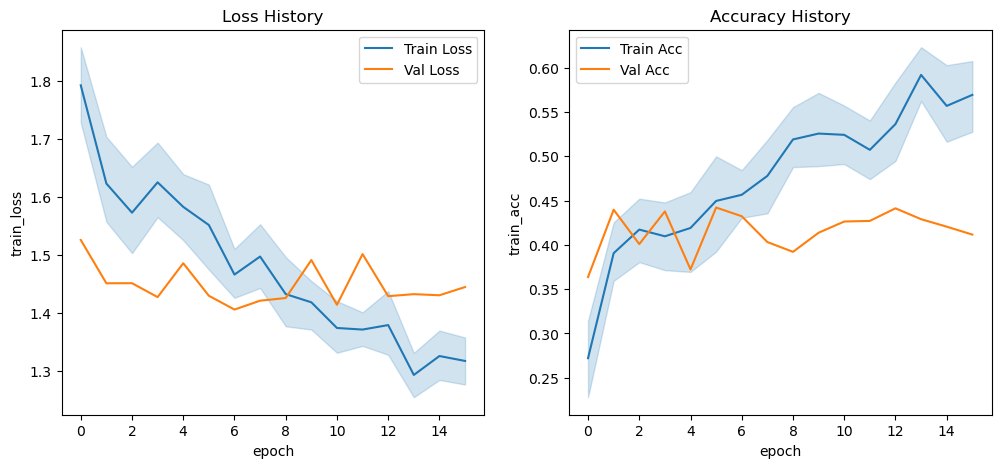

In [ ]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from lightning.pytorch.loggers import CSVLogger
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

if __name__ == "__main__":
    # To run tuning:
    study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
    study.optimize(objective, n_trials=10, callbacks=[print_trial_status])
    
    # ---> ADD THIS BLOCK TO SEE THE HISTORY <---
    print("\n--- OPTUNA TRIALS SUMMARY ---")
    df = study.trials_dataframe()
    
    # Filter it to show just the useful columns (Trial #, Accuracy, and your 4 parameters)
    clean_df = df[['number', 'value', 'params_lr', 'params_batch_size', 'params_weight_decay', 'state']]
    
    # Sort it so the highest accuracy is at the top!
    clean_df = clean_df.sort_values(by='value', ascending=False)
    print(clean_df.to_string(index=False))
    
    # 1. Setup Data
    dm = OPERAnetDataModule(root_dir="doppler_traces", batch_size=study.best_params["batch_size"])

    # 2. Setup Model 
    # (You can pass hyperparams here for Optuna later)
    model = LitSHARP(
        num_classes=8, 
        lr=study.best_params["lr"], 
        weight_decay=study.best_params["weight_decay"]
    )

    # 3. Setup Callbacks (Replaces your manual "Best Model" logic)
    checkpoint_callback = ModelCheckpoint(
        monitor="val_acc",
        dirpath="checkpoints",
        filename="best-sharp",
        mode="max",
        save_top_k=1
    )
    logger = CSVLogger("logs", name="sharp_experiment")
    # 4. The Trainer (Replaces your loops, device config, and tqdm) find parameters
    trainer = L.Trainer(
        num_sanity_val_steps=0,
        max_epochs=30,           # Set your epochs here
        accelerator="auto",      # Auto-detects MPS, CUDA, or CPU
        devices=1,               # Number of GPUs/Chips
        callbacks=[checkpoint_callback, EarlyStopping(monitor="val_acc", patience=15)],
        precision="bf16-mixed",     # Optional: Faster training on modern GPUs
        logger=logger
    )

    # 5. START TRAINING
    trainer.fit(model, datamodule=dm)
    log_path = f"{logger.log_dir}/metrics.csv"
    metrics = pd.read_csv(log_path)

    # 6. START TESTING (Replaces your manual Fusion loop)
    # This automatically loads the BEST checkpoint from the training phase
    
    trainer.test(model, datamodule=dm, ckpt_path="best")

In [ ]:
"""     # 3. Plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.lineplot(data=metrics, x='epoch', y='train_loss', label='Train Loss')
    sns.lineplot(data=metrics, x='epoch', y='val_loss', label='Val Loss')
    plt.title("Loss History")

    plt.subplot(1, 2, 2)
    sns.lineplot(data=metrics, x='epoch', y='train_acc', label='Train Acc')
    sns.lineplot(data=metrics, x='epoch', y='val_acc', label='Val Acc')
    plt.title("Accuracy History")
    plt.show() """

In [53]:
def plot_confusion_matrix(true_labels, pred_labels):
    activity_names = ['Empty', 'Walk', 'Run', 'Jump', 'Sit', 'Stand', 'Sit/Stand', 'Gym']
    
    cm = confusion_matrix(true_labels, pred_labels)
    
    # Normalize the matrix (percentages)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=activity_names, yticklabels=activity_names)
    plt.title('Normalized Confusion Matrix: Subject 7 (Fusion)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

plot_confusion_matrix(model.test_labels, model.test_preds)

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1000x800 with 0 Axes>

Pre-loading data into RAM...
Loaded 28120 windows into RAM.
Pre-loading data into RAM...
Loaded 5692 windows into RAM.


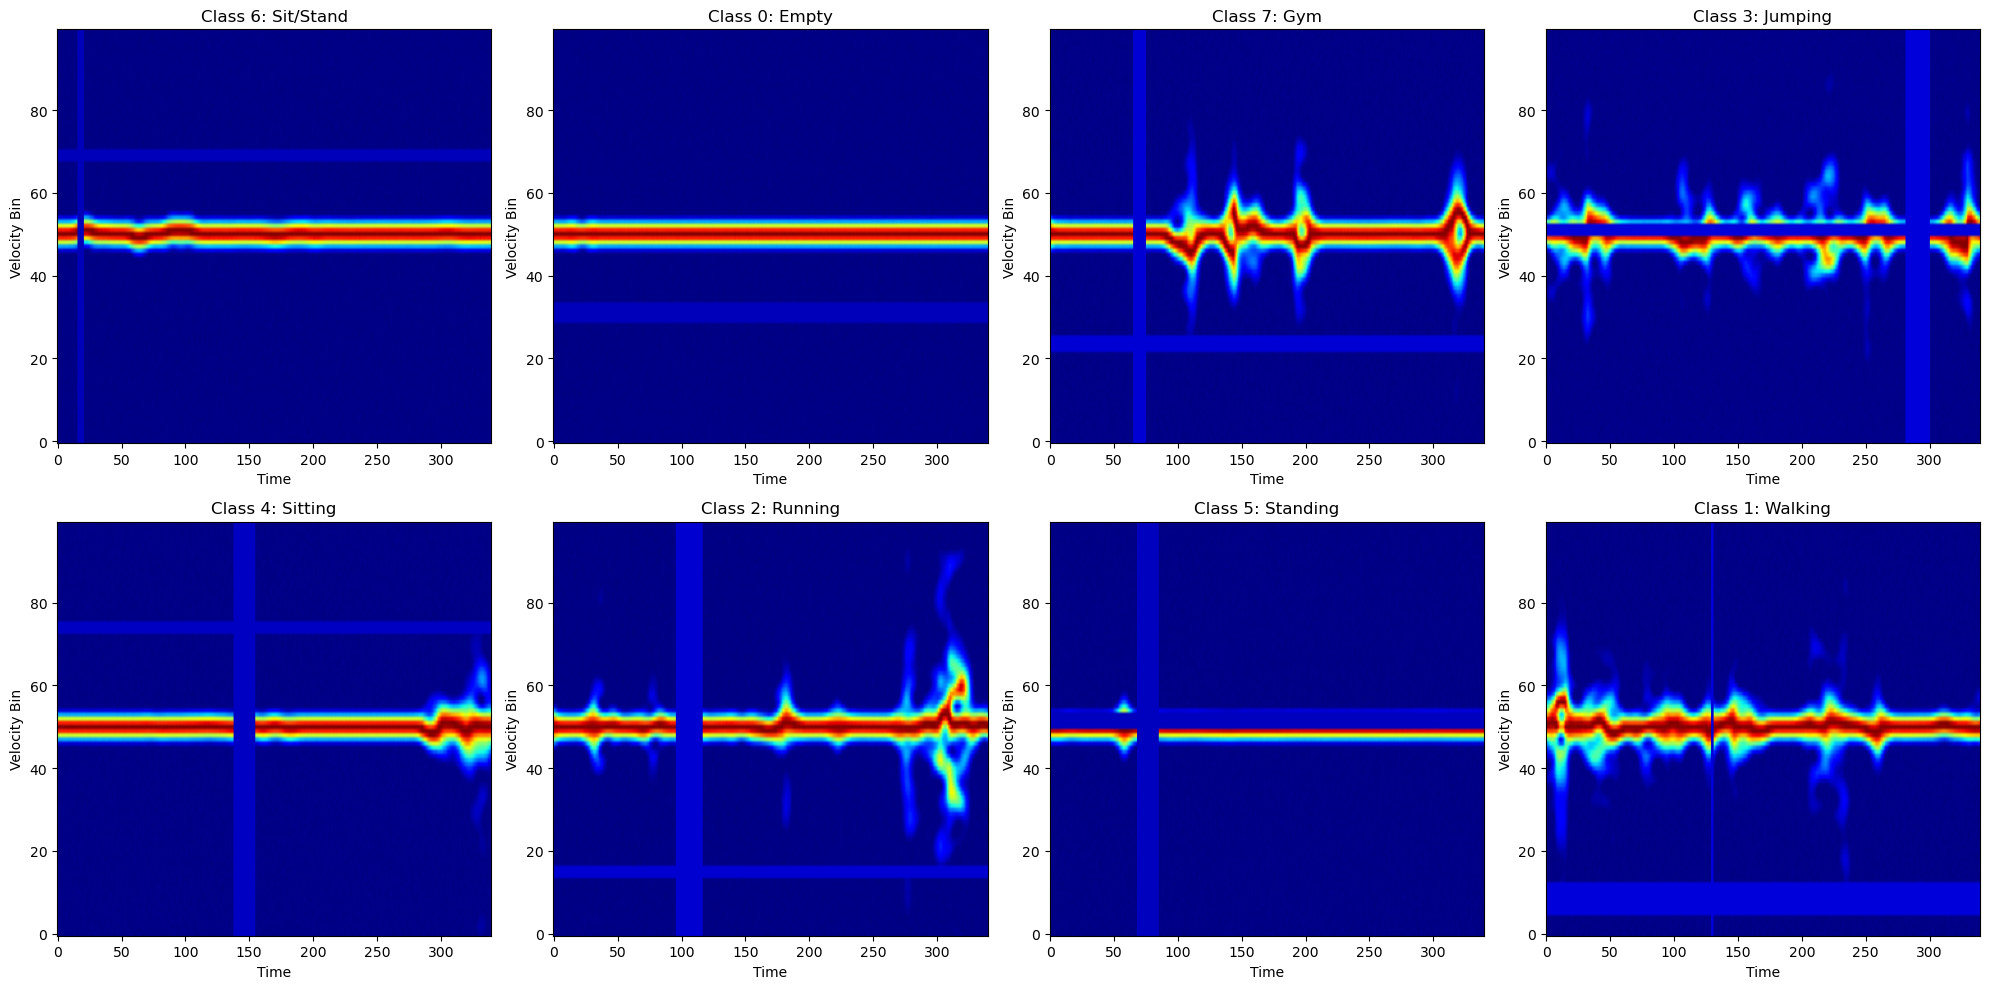

In [54]:
def plot_sample_activities(dataset, label_map):
    # Invert the map to get {ID: Name}
    inv_map = {v: k for k, v in label_map.items()}
    activity_names = {
        0: 'Empty', 1: 'Walking', 2: 'Running', 3: 'Jumping',
        4: 'Sitting', 5: 'Standing', 6: 'Sit/Stand', 7: 'Gym'
    }
    
    found_classes = set()
    plt.figure(figsize=(20, 10))
    
    count = 0
    # Search for one example of each class
    for i in range(len(dataset)):
        x, y = dataset[i]
        label = y.item()
        if label not in found_classes:
            found_classes.add(label)
            count += 1
            
            plt.subplot(2, 4, count)
            # Remove channel dim and plot
            plt.imshow(x.squeeze().numpy().T, aspect='auto', origin='lower', cmap='jet')
            plt.title(f"Class {label}: {activity_names[label]}")
            plt.xlabel("Time")
            plt.ylabel("Velocity Bin")
            
            if len(found_classes) == 8: break
            
    plt.tight_layout()
    plt.show()
# Initialize data
dm = OPERAnetDataModule(root_dir="doppler_traces")
dm.setup() # Manual setup call to initialize the internal datasets

# Use the function from before
# SHARED_LABEL_MAP is the dictionary we defined earlier
plot_sample_activities(dm.train_ds, SHARED_LABEL_MAP)